### Notes

valid_mask checks for 16s gaps of possible missed spikes due to noise. Right now, the dims are n_neurs * n_seconds.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns, glob
from convnwb.io import load_nwbfile

### global variables and helper functions

In [2]:
bin_size = 1 # seconds

def population_fr(df, valid_mask, time_bins, bin_size=bin_size):
    """
    Mean population FR per timebin, using only valid (non-gap) neurons at each bin.
    Returns (mean_fr, std_fr, n_used) — each a 1D array over time_bins.
    """
    spike_matrix = np.zeros((len(df), len(time_bins)))
    for i, (_, row) in enumerate(df.iterrows()):
        spikes = np.array(row['enc_spikes'])
        for t, t_start in enumerate(time_bins):
            spike_matrix[i, t] = np.sum((spikes >= t_start) & (spikes < t_start + bin_size)) / bin_size

    mean_fr, std_fr, n_used = [], [], []
    for t in range(len(time_bins)):
        frs = spike_matrix[valid_mask[:, t], t]
        mean_fr.append(np.mean(frs) if len(frs) > 0 else np.nan)
        std_fr.append(np.std(frs) if len(frs) > 0 else np.nan)
        n_used.append(valid_mask[:, t].sum())

    return np.array(mean_fr), np.array(std_fr), np.array(n_used)


### example session's nwb

In [3]:
sess_file = glob.glob('../../data/000623/sub-CS54/*.nwb')[0]
nwbfile, io = load_nwbfile(os.path.basename(sess_file), os.path.dirname(sess_file), return_io=True)
print(f"Number of units: {len(nwbfile.units)}")
nwbfile

Number of units: 123


Data type,int64
Shape,"(603,)"
Array size,4.71 KiB
Chunk shape,None
Compression,None
Compression opts,None
Compression ratio,1.0
Data type,float64
Shape,"(603,)"
Array size,4.71 KiB
Chunk shape,None


### concatenate into giant df

In [4]:
# df_neurs = pd.DataFrame(columns=['subj', 'sess', 'hemi', 'region', 'neur_id', 'base_start', 'base_stop', 'enc_spikes', 'base_spikes'])

# sess_files = glob.glob('../../data/000623/sub-*/*.nwb')

# for sess_file in sess_files:

#     nwbfile, io = load_nwbfile(os.path.basename(sess_file), os.path.dirname(sess_file), return_io=True)

#     df_trials = nwbfile.trials.to_dataframe()
#     df_units = nwbfile.units.to_dataframe()[['unit_id_session', 'electrode_id', 'spike_times']]
#     df_electrodes = nwbfile.electrodes.to_dataframe()

#     # session info
#     df_units['subj'], df_units['sess'] = nwbfile.subject.subject_id, nwbfile.session_id 
#     df_units['base_start'], df_units['base_stop'] = df_trials['stop_time'].iloc[0], df_trials['start_time'].iloc[1]

#     # neur info
#     df_units = df_units.rename(columns={'unit_id_session': 'neur_id'})

#     # split spikes into enc & base
#     df_units['enc_spikes'], df_units['base_spikes'] = None, None
#     for id, neur in df_units.iterrows():
#         spikes = neur['spike_times']
#         enc_spikes = spikes[spikes < neur['base_start']]
#         base_spikes = spikes[(spikes >= neur['base_start']) & (spikes < neur['base_stop'])]
#         df_units.at[id, 'enc_spikes'] = sorted(enc_spikes.tolist())
#         df_units.at[id, 'base_spikes'] = sorted(base_spikes.tolist())

#     # electrode info
#     df_units['electrode_id'] = df_units['electrode_id'].map(df_electrodes['location'])
#     df_units['hemi'] = df_units['electrode_id'].str.split().str[0]
#     df_units['region'] = df_units['electrode_id'].str.split().str[1]

#     # sort
#     df_units = df_units[['subj', 'sess', 'hemi', 'region', 'neur_id', 'base_start', 'base_stop', 'enc_spikes', 'base_spikes']]
#     df_units = df_units.sort_values('region').reset_index(drop=True)

#     df_neurs = pd.concat([df_neurs, df_units[['subj', 'sess', 'hemi', 'region', 'neur_id', 'base_start', 'base_stop', 'enc_spikes', 'base_spikes']]], ignore_index=True)

# df_neurs.to_parquet('../data/csvs/df_neurs.parquet', index=False)


### show dfs

In [5]:
df_neurs = pd.read_parquet('../data/csvs/df_neurs.parquet')
df_neurs

,subj,sess,hemi,region,neur_id,base_start,base_stop,enc_spikes,base_spikes
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744...","[480.504041, 480.822666, 481.2748535, 481.3912..."
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,...","[484.50519625, 484.55057125, 486.2016015, 486...."
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707...","[488.7439755, 489.63731925]"
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ...","[478.920417, 478.9386045, 479.02932325, 479.03..."
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175...","[480.52132225, 481.14500975, 481.2111035, 481...."
...,...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325...","[479.55532375, 479.90207375, 479.90851125, 481..."
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0...","[478.9684175, 479.19073, 481.5164165, 482.3733..."
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087...","[483.2832905, 484.68175925, 484.84519675, 486...."
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1...","[480.00151025, 486.47719575, 486.615352, 488.3..."


In [6]:
P54CSR1 = df_neurs[df_neurs['sess'] == 'P54CSR1'].copy().reset_index(drop=True)
P54CSR1 = P54CSR1.drop(columns=['subj', 'sess', 'base_start', 'base_stop', 'base_spikes'])
print('example session data')
P54CSR1


example session data


,hemi,region,neur_id,enc_spikes
0,Right,ACC,P54CS_R1_38_2_4348_5,"[0.354859, 1.358859, 2.38720275, 2.724983, 5.0..."
1,Right,ACC,P54CS_R1_34_1_1248_5,"[0.11889025, 0.150359, 1.10526525, 1.41520275,..."
2,Right,ACC,P54CS_R1_38_3_4373_5,"[0.5274215, 0.548109, 0.8279215, 0.876234, 0.9..."
3,Right,ACC,P54CS_R1_38_1_4293_5,"[0.18764025, 0.47132775, 0.702734, 1.0887965, ..."
4,Left,amygdala,P54CS_R1_19_2_6713_4,"[0.84014025, 0.84401525, 1.41314025, 1.4807027..."
...,...,...,...,...
118,Left,vmPFC,P54CS_R1_65_3_5609_10,"[2.24682775, 2.2542965, 3.02970175, 4.58932675..."
119,Left,vmPFC,P54CS_R1_65_2_5598_10,"[0.24414025, 0.402359, 0.53864025, 0.81889025,..."
120,Right,vmPFC,P54CS_R1_79_2_1239_9,"[2.993483, 2.9994205, 4.9167955, 6.4526695, 7...."
121,Left,vmPFC,P54CS_R1_70_1_5052_10,"[0.02839025, 0.064109, 0.3509215, 1.65995275, ..."


### compute basic metrics and exclusions

In [17]:
# durations and firing rates
df_neurs['base_duration'] = df_neurs['base_stop'] - df_neurs['base_start']
df_neurs['enc_duration'] = df_neurs['base_start']
df_neurs['base_spike_count'] = df_neurs['base_spikes'].apply(len)
df_neurs['enc_spike_count'] = df_neurs['enc_spikes'].apply(len)
df_neurs['base_firing_rate'] = df_neurs['base_spike_count'] / df_neurs['base_duration']
df_neurs['enc_firing_rate'] = df_neurs['enc_spike_count'] / df_neurs['enc_duration']

# exclude neurons with enc FR < 0.5 (computed on full duration before trimming)
print(f'total neurons: {len(df_neurs)}')
df_all_clean_data = df_neurs[df_neurs['enc_firing_rate'] >= 0.5].copy()
print(f"Remaining after FR filter: {len(df_all_clean_data)} neurons")

# trim all neurons to the shortest recording so they share the same time axis
min_enc_time = df_all_clean_data['enc_duration'].min()
df_all_clean_data['enc_spikes'] = df_all_clean_data['enc_spikes'].apply(
    lambda spikes: [s for s in spikes if s < min_enc_time]
)
df_all_clean_data['enc_duration'] = min_enc_time
df_all_clean_data['enc_spike_count'] = df_all_clean_data['enc_spikes'].apply(len)
df_all_clean_data['enc_firing_rate'] = df_all_clean_data['enc_spike_count'] / min_enc_time
print(f"Trimmed enc_duration to min: {min_enc_time}s")

# shared time axis for all neurons
time_bins = np.arange(0, min_enc_time, bin_size)
print(len(time_bins), "time bins of size", bin_size, "seconds each")

total neurons: 1457
Remaining after FR filter: 1123 neurons
Trimmed enc_duration to min: 478.01962s
479 time bins of size 1 seconds each


### take care of 16s missing spike periods

Neurons with 16+ second gaps: 145 / 1123
Total 16+ second gaps: 318
valid_mask: (1123, 479), 98.7% valid entries


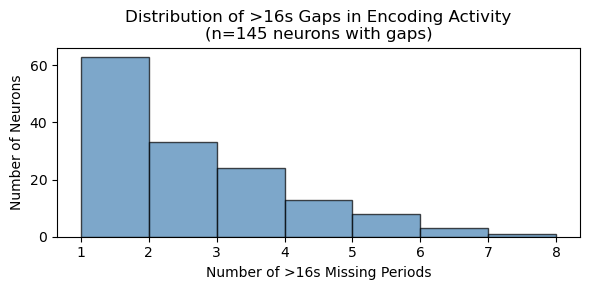

In [8]:
# valid_mask[i, t] = False if neuron i had a >=16s spike gap covering timebin t
valid_mask = np.ones((len(df_all_clean_data), len(time_bins)), dtype=bool)  # start all-valid
df_all_clean_data['num_gaps_16s'] = 0

for i, (idx, row) in enumerate(df_all_clean_data.iterrows()): # loop over neurons
    spikes = row['enc_spikes']  # sorted list of spike times in seconds
    num_gaps = 0
    for j in range(len(spikes) - 1):
        gap_start, gap_end = spikes[j], spikes[j + 1]  # consecutive spike pair
        if gap_end - gap_start >= 16:  # inter-spike interval >= 16s
            num_gaps += 1
            # boolean index: which time_bins fall inside this gap
            valid_mask[i, (time_bins >= gap_start) & (time_bins < gap_end)] = False
    df_all_clean_data.at[idx, 'num_gaps_16s'] = num_gaps  # store per-neuron gap count

has_gaps = df_all_clean_data[df_all_clean_data['num_gaps_16s'] > 0]
print(f"Neurons with 16+ second gaps: {len(has_gaps)} / {len(df_all_clean_data)}")
print(f"Total 16+ second gaps: {has_gaps['num_gaps_16s'].sum()}")
print(f"valid_mask: {valid_mask.shape}, {valid_mask.mean()*100:.1f}% valid entries")

# plot only neurons that actually have gaps (num_gaps_16s == 0 would be a single bar at 0)
gaps_only = df_all_clean_data[df_all_clean_data['num_gaps_16s'] > 0]
plt.figure(figsize=(6, 3))
# bins=range(1, max+2) ensures each integer gap count gets its own bar
plt.hist(gaps_only['num_gaps_16s'], bins=range(1, gaps_only['num_gaps_16s'].max() + 2),
         color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Number of >16s Missing Periods')
plt.ylabel('Number of Neurons')
plt.title(f'Distribution of >16s Gaps in Encoding Activity\n(n={len(gaps_only)} neurons with gaps)')
plt.tight_layout()
plt.show()


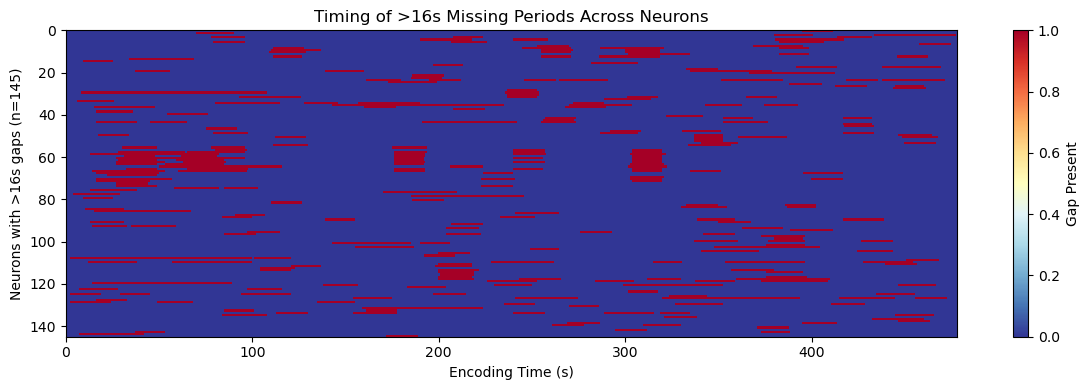

In [9]:
gaps_neurons = df_all_clean_data[df_all_clean_data['num_gaps_16s'] > 0]
# integer row positions into valid_mask (df index != row position after filtering)
gap_indices = [df_all_clean_data.index.get_loc(idx) for idx in gaps_neurons.index]

# all neurons have the same length now — use valid_mask rows directly, no resampling needed
heatmap_data = (~valid_mask[gap_indices]).astype(float)  # 1=gap, 0=valid

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlBu_r', interpolation='nearest',
               extent=[0, min_enc_time, len(gaps_neurons), 0])  # maps columns to real seconds
ax.set(xlabel='Encoding Time (s)', ylabel=f'Neurons with >16s gaps (n={len(gaps_neurons)})',
       title='Timing of >16s Missing Periods Across Neurons')
plt.colorbar(im, ax=ax, label='Gap Present')
plt.tight_layout()
plt.show()


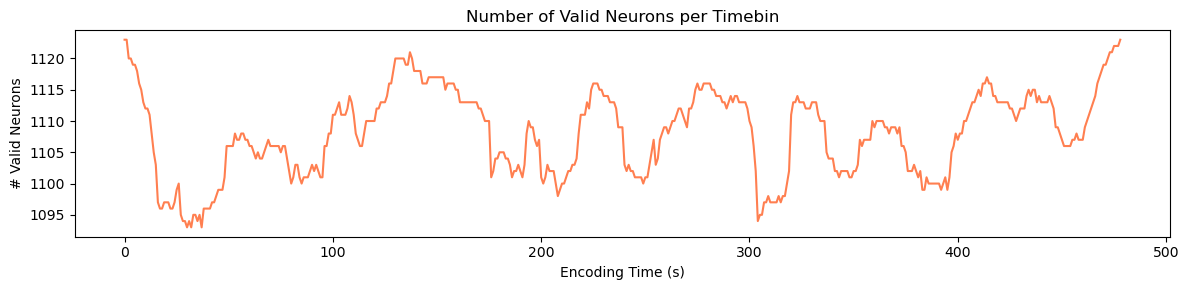

In [10]:
# valid_enc_duration: count valid bins per neuron, convert to seconds
df_all_clean_data['valid_enc_duration'] = valid_mask.sum(axis=1) * bin_size
df_all_clean_data['enc_firing_rate_valid'] = df_all_clean_data['enc_spike_count'] / df_all_clean_data['valid_enc_duration']

# all_mask: baseline — treat every bin as valid, to compare against gap-corrected FR
all_mask = np.ones_like(valid_mask)
mean_fr_all, std_fr_all, _ = population_fr(df_all_clean_data, all_mask, time_bins)
mean_fr, std_fr, n_used = population_fr(df_all_clean_data, valid_mask, time_bins)

# n_used[t] = number of neurons with a valid bin at time t
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(time_bins, n_used, color='coral')
ax.set(title='Number of Valid Neurons per Timebin', ylabel='# Valid Neurons', xlabel='Encoding Time (s)')
plt.tight_layout()
plt.show()


### basic checks

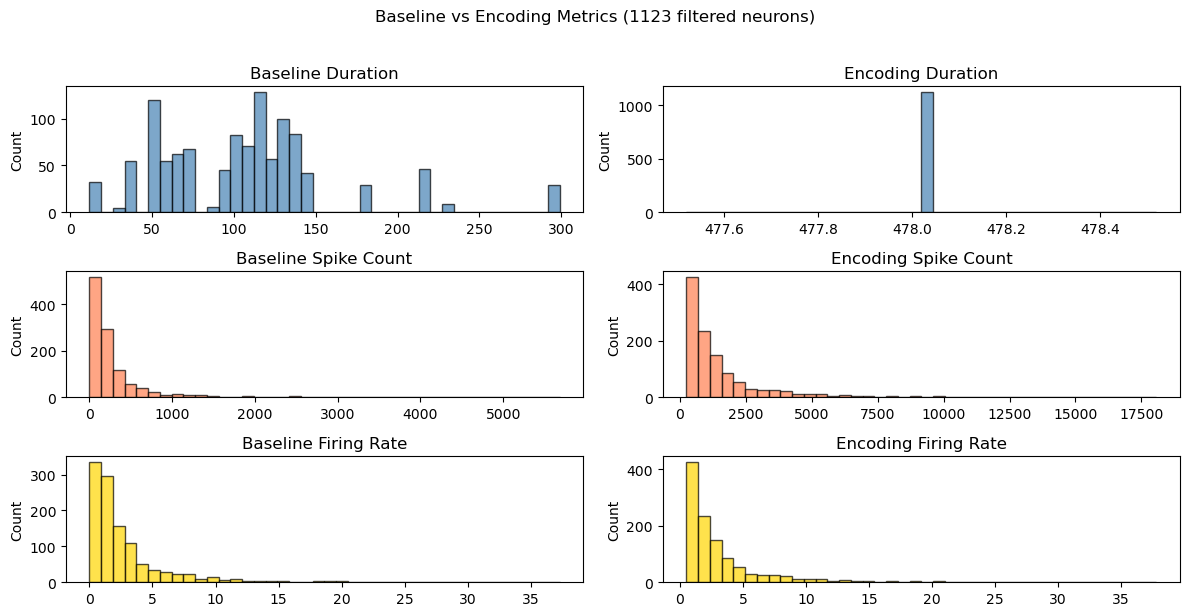

In [19]:
# Baseline vs encoding metric distributions
fig, axs = plt.subplots(3, 2, figsize=(12, 6))
axs, ax = axs.flatten(), 0

for base_col, enc_col, title, color in [
    ('base_duration', 'enc_duration', 'Duration', 'steelblue'),
    ('base_spike_count', 'enc_spike_count', 'Spike Count', 'coral'),
    ('base_firing_rate', 'enc_firing_rate', 'Firing Rate', 'gold')
]:
    axs[ax].hist(df_all_clean_data[base_col], bins=40, color=color, edgecolor='black', alpha=0.7)
    axs[ax].set(title=f'Baseline {title}', ylabel='Count')
    ax += 1
    axs[ax].hist(df_all_clean_data[enc_col], bins=40, color=color, edgecolor='black', alpha=0.7)
    axs[ax].set(title=f'Encoding {title}', ylabel='Count')
    ax += 1

plt.suptitle(f'Baseline vs Encoding Metrics ({len(df_all_clean_data)} filtered neurons)', y=1.02)
plt.tight_layout()
plt.show()

### save a df_spikes, which is neur*time in shape

In [11]:
# Build spike matrix: neurons x time_bins (FR in Hz per bin)
spike_matrix = np.zeros((len(df_all_clean_data), len(time_bins)))
for i, (_, row) in enumerate(df_all_clean_data.iterrows()):
    spikes = np.array(row['enc_spikes'])
    for t, t_start in enumerate(time_bins):
        spike_matrix[i, t] = np.sum((spikes >= t_start) & (spikes < t_start + bin_size)) / bin_size

df_spikes = pd.DataFrame(spike_matrix, columns=time_bins, index=df_all_clean_data.index)
df_spikes

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,469.0,470.0,471.0,472.0,473.0,474.0,475.0,476.0,477.0,478.0
3,5.0,3.0,10.0,33.0,17.0,20.0,26.0,22.0,17.0,23.0,...,21.0,19.0,13.0,15.0,13.0,12.0,12.0,11.0,16.0,1.0
4,3.0,0.0,1.0,3.0,0.0,0.0,2.0,1.0,3.0,1.0,...,1.0,1.0,3.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0
5,1.0,2.0,2.0,2.0,0.0,1.0,1.0,2.0,0.0,4.0,...,3.0,0.0,5.0,3.0,2.0,1.0,2.0,1.0,3.0,0.0
6,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,1.0,3.0,3.0,2.0,1.0,1.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,2.0,4.0,2.0,4.0,2.0,3.0,1.0,8.0,1.0,4.0,...,1.0,0.0,2.0,2.0,0.0,1.0,4.0,4.0,2.0,0.0
1453,12.0,3.0,10.0,3.0,8.0,3.0,4.0,7.0,2.0,5.0,...,5.0,7.0,5.0,5.0,5.0,10.0,1.0,4.0,2.0,0.0
1454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,1.0,1.0,1.0,2.0,2.0,0.0,2.0,0.0
1455,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2.0,2.0,0.0,2.0,0.0,1.0,2.0,1.0,1.0,0.0


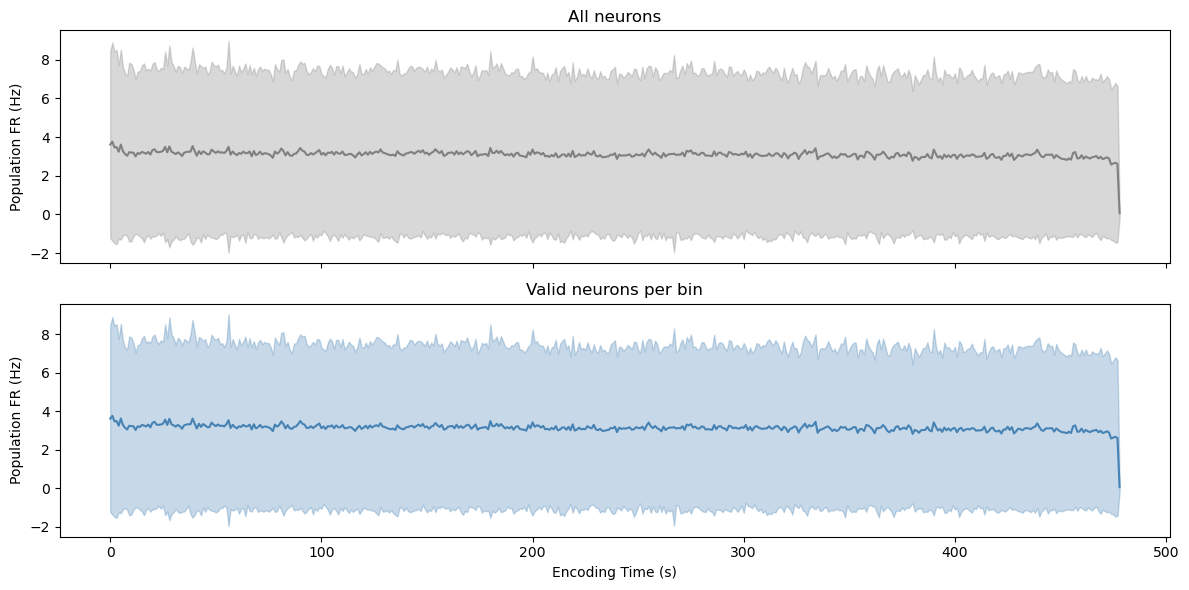

In [12]:
# Population FR plots
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(time_bins, mean_fr_all, color='gray')
axs[0].fill_between(time_bins, mean_fr_all - std_fr_all, mean_fr_all + std_fr_all, alpha=0.3, color='gray')
axs[0].set(ylabel='Population FR (Hz)', title='All neurons')
axs[1].plot(time_bins, mean_fr, color='steelblue')
axs[1].fill_between(time_bins, mean_fr - std_fr, mean_fr + std_fr, alpha=0.3, color='steelblue')
axs[1].set(ylabel='Population FR (Hz)', xlabel='Encoding Time (s)', title='Valid neurons per bin')
plt.tight_layout()
plt.show()


### save outputs

In [20]:
out_dir = '../data/csvs'
os.makedirs(out_dir, exist_ok=True)

df_all_clean_data.to_parquet(f'{out_dir}/df_all_clean_data.parquet', index=True)
df_spikes.to_parquet(f'{out_dir}/df_spikes.parquet')
np.save(f'{out_dir}/valid_mask.npy', valid_mask)
np.save(f'{out_dir}/time_bins.npy', time_bins)

print(f'total neurons: {len(df_neurs)}')
print(f"Filtered neurons with enc FR >= 0.5: {len(df_all_clean_data)}")
print(f"Saved df_all_clean_data ({df_all_clean_data.shape[0]} neurons x {df_all_clean_data.shape[1]} cols) → {out_dir}/df_all_clean_data.parquet")
print()
# print bin size and time bins
print(f"Bin size: {bin_size} seconds, #Time bins: {len(time_bins)}")
print(f"Saved df_spikes ({df_spikes.shape[0]} neurons x {df_spikes.shape[1]} time bins) → {out_dir}/df_spikes.parquet")
print(f"Saved valid_mask {valid_mask.shape} → {out_dir}/valid_mask.npy")


total neurons: 1457
Filtered neurons with enc FR >= 0.5: 1123
Saved df_all_clean_data (1123 neurons x 15 cols) → ../data/csvs/df_all_clean_data.parquet

Bin size: 1 seconds, #Time bins: 479
Saved df_spikes (1123 neurons x 479 time bins) → ../data/csvs/df_spikes.parquet
Saved valid_mask (1123, 479) → ../data/csvs/valid_mask.npy


### looping through gaze data

In [15]:
# from ephys_utills import get_et_timebins, compute_pixelperDVA, et_heatmap

# SEC2MSEC = 1000.
# nwb_input_dir = '../../data/000623/'

# # ----- Basic metadata info about the video stimulus -----
# frame_width, frame_height, vid_fps, nframes = 640, 480, 25.0, 11971
# vid_fps, nframes = 29.97, 14351 # 11971/25*29.97

# frame_duration_msec = SEC2MSEC / vid_fps
# framesize = [frame_width, frame_height]

# # define a duration to timebin the ET data
# ########################################################################################################################################################################## divided by vid_fps
# timebin_sec = 1.0/vid_fps # define here as sec. used for saving results
# timebin_msec = timebin_sec * SEC2MSEC # millisec.

# nbins = np.round(frame_duration_msec * nframes / timebin_msec).astype(int)

# nwb_session_files = sorted(glob.glob(os.path.join(nwb_input_dir, 'sub-*/*.nwb')))

# # ----- Read ET (gaze) data from the NWB files -----
# etdata_ses = []
# pixel_dva_ses = []
# missingdata_ratio = []
# session_ids_et = []
# select_subj_id, i = 0, 0


# for session_ii in nwb_session_files:

#     print(f'processing {os.path.basename(session_ii)}...')

#     # Open the NWB file and read its content
#     with NWBHDF5IO(session_ii,'r') as nwb_io: 
#         nwbfile = nwb_io.read()
        
#         session_ids_et.append(nwbfile.identifier)
        
#         trials_df = nwbfile.trials.to_dataframe()
#         enc_start_time = trials_df[trials_df['stim_phase']=='encoding']['start_time'].values[0]
#         enc_stop_time = trials_df[trials_df['stim_phase']=='encoding']['stop_time'].values[0]
        
#         gaze_data = nwbfile.processing['behavior']['EyeTracking']['SpatialSeries']
#         gaze_xy = np.asarray(gaze_data.data)
        
#         if gaze_data.rate is None:
#             gaze_time = gaze_data.timestamps
#         else:
#             gaze_time = np.arange(0,len(gaze_xy))/(gaze_data.rate) + gaze_data.starting_time
#         gaze_encoding = np.logical_and(gaze_time >= enc_start_time, 
#                                         gaze_time <= enc_stop_time) 
    
#         gaze_df = pd.DataFrame(data=np.c_[gaze_time[gaze_encoding],gaze_xy[gaze_encoding,:]],
#                                 columns=['RecTime','GazeX','GazeY'])    
    
#         # get video display info and scale gaze to stimulus size
#         display_info_raw = gaze_data.comments
#         screen_wh, display_wh, display_area_i = display_info_raw.split('::')
    
#         screen_w, screen_h = list(map(float,screen_wh.split('=')[1].split(',')))
#         display_w, display_h = list(map(float,display_wh.split('=')[1].split(',')))
#         display_area = list(map(float,display_area_i.split('=')[1].split(',')))
    
#         _, pixel_dva_mean = compute_pixelperDVA([screen_w,screen_h])
#         pixel_dva_ses.append(pixel_dva_mean)
    
#         scale_dx = frame_width / display_w
#         scale_dy = frame_height / display_h
    
#         gaze_df['GazeX'] = (gaze_df['GazeX'] - display_area[0])*scale_dx 
#         gaze_df['GazeY'] = (gaze_df['GazeY'] - display_area[1])*scale_dy 
    
#         problem_inds_x = np.logical_not(gaze_df['GazeX'].astype(float).between(0,frame_width,
#                                                                                 inclusive='left'))
        
#         problem_inds_y = np.logical_not(gaze_df['GazeY'].astype(float).between(0,frame_height,
#                                                                                 inclusive='left'))
#         problem_inds = np.logical_or(problem_inds_x, problem_inds_y)
#         gaze_df.loc[problem_inds,['GazeX','GazeY']] = np.nan
        
#         # ###############################################################################################################################################
#         # # do_op was originally None
#         # # Downsample gaze data to the video frame rate
#         # et_xy_binned = get_et_timebins(gaze_df, timebin_msec, do_op=None, 
#         #                                 fix_length=True, nbins=nbins, keep_timebin_index=False,)
        
#         # # sid's code
#         # # et_xy_binned is a list of length nbins, where each entry is [array(GazeX), array(GazeY)]
#         # # Convert to an object array of shape (nbins, 2)
#         # et_arr = np.asarray(et_xy_binned, dtype=object)  # et_arr[t,0] is array of GazeX for bin t

#         # # Now compute nanmean per bin for X and Y:
#         # gaze_x_list = []
#         # gaze_y_list = []

#         # for t in range(nbins):
#         #     arr_t = et_arr[t]             # get the full (n×2) array for bin t
#         #     x_vals = arr_t[:, 0].astype(float)
#         #     y_vals = arr_t[:, 1].astype(float)
#         #     gaze_x_list.append(np.nanmean(x_vals))  # mean of valid X’s in bin t
#         #     gaze_y_list.append(np.nanmean(y_vals))  # mean of valid Y’s in bin t

#         # # gaze_x_list and gaze_y_list are now length=nbins, with NaNs only if the entire bin was NaN

#         ## sid's code
#         rec_time_list, gaze_x_list, gaze_y_list = gaze_df['RecTime'].tolist(), gaze_df['GazeX'].tolist(), gaze_df['GazeY'].tolist()

#         df_sess = pd.DataFrame({
#             'subj':  [nwbfile.subject.subject_id],
#             'sess':  [nwbfile.session_id],
#             'RecTime': [rec_time_list],
#             'GazeX': [gaze_x_list],
#             'GazeY': [gaze_y_list]
#         })
#         print(len(rec_time_list), len(gaze_x_list), len(gaze_y_list))

#         # df_sess.to_csv(f'../results/csvs/gaze/{nwbfile.session_id}_gaze.csv', index=False)
#         df_sess.to_parquet(f'../results/csvs/gaze/{nwbfile.session_id}_gaze.parquet', index=False)

# df_sess